# 01. Analyse Exploratoire des Données (EDA)

Objectif : Evaluer la qualité de la base de données, évaluer la distribution du risque de défaut (loan_status) et identifier les facteurs de risque les plus discriminants.

Nous importons les librairies nécessaires de data science, analyse statistique et visualisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Configuration du style graphique

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

Nous chargeons le jeu de données loan_default_prediction.csv et faisons un premier contrôle de volumétrie.

In [7]:
df = pd.read_csv("../data/raw/loan_default_prediction.csv")

print(f"Dimensions du jeu de données : {df.shape[0]} emprunteurs, {df.shape[1]} variables.")
display(df.head())

Dimensions du jeu de données : 1000 emprunteurs, 13 variables.


,loan_id,age,income,employment_years,credit_score,loan_amount,loan_term_months,interest_rate,debt_to_income,home_ownership,loan_purpose,previous_defaults,loan_status
0,L000001,40,24096,19,733,37103,36,13.72,0.56,Own,Business,0,1
1,L000002,31,148113,14,411,21845,12,8.58,0.25,Mortgage,Personal,2,1
2,L000003,59,59861,22,810,41554,24,8.32,0.25,Mortgage,Auto,0,0
3,L000004,46,56283,39,471,48565,24,15.88,0.65,Own,Business,0,1
4,L000005,49,34226,8,654,14193,24,4.57,0.36,Rent,Personal,0,0


Nous vérifions l'absence de valeurs manquantes, la détection des doublons sur l'identifiant (loan_id) et la cohérence des types.

In [8]:
data_quality = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs Manquantes': df.isnull().sum(),
    'Taux Manquants (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Valeurs Uniques': df.nunique()
})

print("=== Bilan de Qualité des Données ===")
display(data_quality)
print(f"Nombre de doublons d'identifiants (loan_id) : {df['loan_id'].duplicated().sum()}")

=== Bilan de Qualité des Données ===


,Type,Valeurs Manquantes,Taux Manquants (%),Valeurs Uniques
loan_id,str,0,0.0,1000
age,int64,0,0.0,50
income,int64,0,0.0,999
employment_years,int64,0,0.0,41
credit_score,int64,0,0.0,466
loan_amount,int64,0,0.0,990
loan_term_months,int64,0,0.0,4
interest_rate,float64,0,0.0,718
debt_to_income,float64,0,0.0,76
home_ownership,str,0,0.0,3


Nombre de doublons d'identifiants (loan_id) : 0


La variable dépendante loan_status indique le statut de l'emprunteur (0 = Sain, 1 = En défaut). Nous mesurons le taux de défaut global de la cohorte d'apprentissage

Emprunteurs Sains (0)       : 423 (42.30%)
Emprunteurs Défaillants (1) : 577 (57.70%)


C:\Users\agarn\AppData\Local\Temp\ipykernel_20336\1672337405.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sain (0)', 'Défaillant (1)'], y=target_props.values, ax=ax, palette=['#2ecc71', '#e74c3c'])


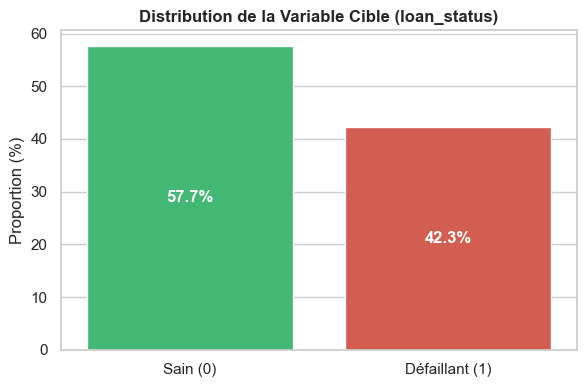

In [9]:
target_counts = df['loan_status'].value_counts()
target_props = df['loan_status'].value_counts(normalize=True) * 100

print(f"Emprunteurs Sains (0)       : {target_counts[0]} ({target_props[0]:.2f}%)")
print(f"Emprunteurs Défaillants (1) : {target_counts[1]} ({target_props[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Sain (0)', 'Défaillant (1)'], y=target_props.values, ax=ax, palette=['#2ecc71', '#e74c3c'])
ax.set_ylabel("Proportion (%)")
ax.set_title("Distribution de la Variable Cible (loan_status)", fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

On calcule les indicateurs de tendance centrale (moyenne, médiane) et de dispersion (écart-type, quantiles) pour détecter la présence de valeurs extrêmes ou asymétriques.

In [10]:
num_features = ['age', 'income', 'employment_years', 'credit_score', 
                'loan_amount', 'loan_term_months', 'interest_rate', 'debt_to_income']

summary_stats = df[num_features].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats.columns = ['Moyenne', 'Écart-Type', 'Min', 'Q1 (25%)', 'Médiane (50%)', 'Q3 (75%)', 'Max']
summary_stats.round(2)

,Moyenne,Écart-Type,Min,Q1 (25%),Médiane (50%),Q3 (75%),Max
age,45.38,14.92,21.00,32.00,46.00,58.00,70.00
income,84518.78,38697.00,15108.00,52309.25,85117.50,118513.50,149880.00
employment_years,19.66,11.71,0.00,9.00,20.00,29.00,40.00
credit_score,576.60,159.21,300.00,442.75,568.50,718.25,850.00
loan_amount,25448.67,14103.07,1034.00,13269.50,25930.00,37395.25,49994.00
loan_term_months,33.18,18.31,12.00,12.00,24.00,60.00,60.00
interest_rate,10.48,4.19,3.04,6.86,10.32,14.02,17.97
debt_to_income,0.43,0.23,0.05,0.24,0.44,0.64,0.80


On analyse les fréquences pour le statut d'occupation du logement (home_ownership), le motif du prêt (loan_purpose) et le nombre d'incidents antérieurs (previous_defaults).

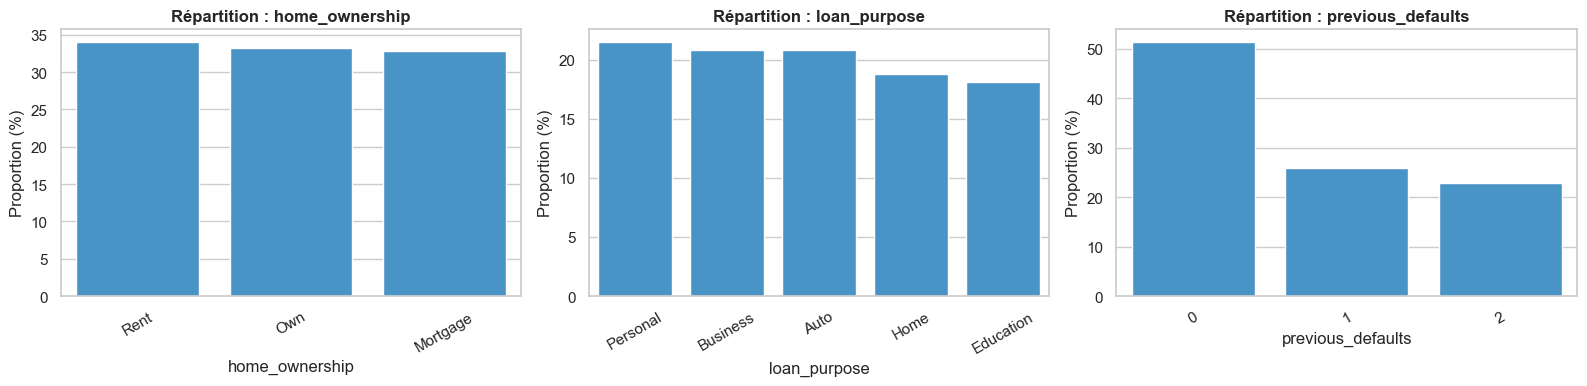

In [11]:
cat_features = ['home_ownership', 'loan_purpose', 'previous_defaults']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, col in enumerate(cat_features):
    counts = df[col].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], color='#3498db')
    axes[idx].set_title(f"Répartition : {col}", fontweight='bold')
    axes[idx].set_ylabel("Proportion (%)")
    axes[idx].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

On compare le profil moyen des clients sains vs défaillants et on évalue le taux de défaut conditionnel en fonction du nombre d'incidents bancaires passés.

In [12]:
# Comparaison des moyennes par classe de risque
risk_profile = df.groupby('loan_status')[num_features].mean().T
risk_profile.columns = ['Moyenne_Sains_0', 'Moyenne_Defaillants_1']
risk_profile['Écart_Relatif_%'] = ((risk_profile['Moyenne_Defaillants_1'] - risk_profile['Moyenne_Sains_0']) / risk_profile['Moyenne_Sains_0'] * 100).round(2)

print("=== Comparaison des Profils de Risque ===")
display(risk_profile)

# Taux de défaut conditionnel selon previous_defaults
def_rate_defaults = df.groupby('previous_defaults')['loan_status'].agg(['count', 'mean'])
def_rate_defaults.columns = ['Effectif', 'Taux_de_Defaut']
def_rate_defaults['Taux_de_Defaut_%'] = (def_rate_defaults['Taux_de_Defaut'] * 100).round(2)

print("\n=== Taux de Défaut par Incidents Antérieurs ===")
display(def_rate_defaults)

=== Comparaison des Profils de Risque ===


,Moyenne_Sains_0,Moyenne_Defaillants_1,Écart_Relatif_%
age,44.990544,45.660312,1.49
income,82163.049645,86245.769497,4.97
employment_years,19.330969,19.892548,2.91
credit_score,614.359338,548.925477,-10.65
loan_amount,25226.617021,25611.450607,1.53
loan_term_months,32.624113,33.587522,2.95
interest_rate,10.478369,10.482773,0.04
debt_to_income,0.389243,0.468042,20.24



=== Taux de Défaut par Incidents Antérieurs ===


,Effectif,Taux_de_Defaut,Taux_de_Defaut_%
previous_defaults,,,
0,513,0.481481,48.15
1,258,0.620155,62.02
2,229,0.742358,74.24


On fait une représentation graphique de la séparation entre emprunteurs sains et défaillants sur le creditèscore, le ration d'endettement (debt_to_income) et les antécédents de défaut (previous_defaults).

C:\Users\agarn\AppData\Local\Temp\ipykernel_20336\382685722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='credit_score', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\agarn\AppData\Local\Temp\ipykernel_20336\382685722.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sain (0)', 'Défaillant (1)'])
C:\Users\agarn\AppData\Local\Temp\ipykernel_20336\382685722.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='loan_status', y='debt_to_income', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\agarn\AppData\Local\Temp\ipykernel_

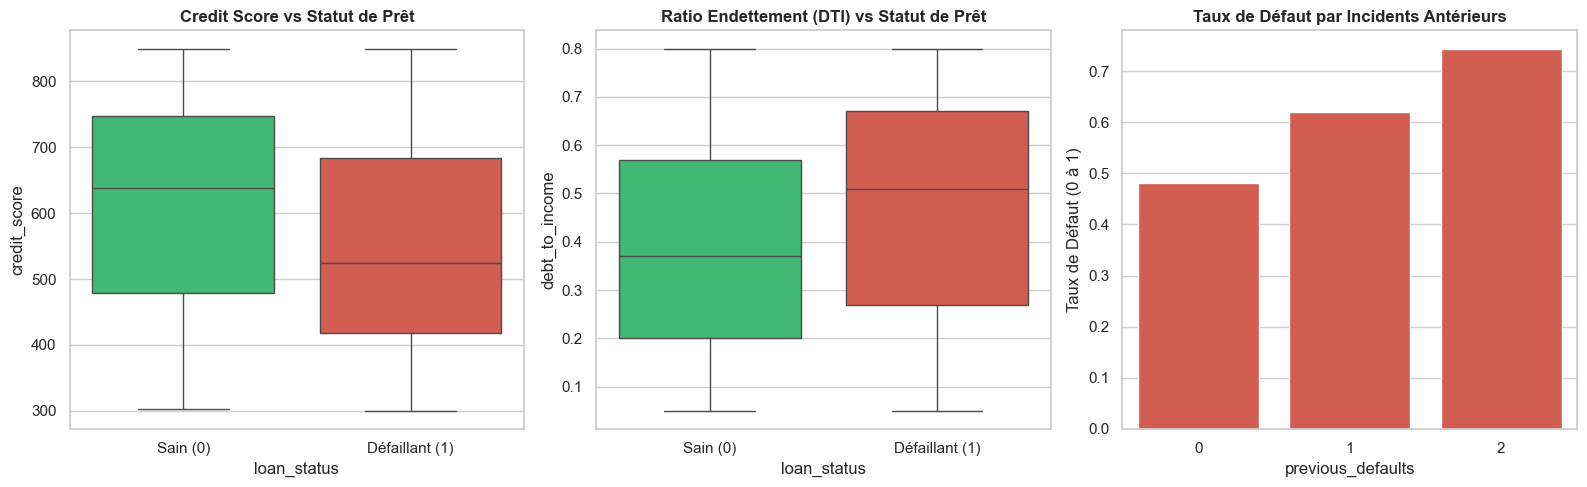

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit Score
sns.boxplot(data=df, x='loan_status', y='credit_score', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title("Credit Score vs Statut de Prêt", fontweight='bold')
axes[0].set_xticklabels(['Sain (0)', 'Défaillant (1)'])

# Debt to Income (DTI)
sns.boxplot(data=df, x='loan_status', y='debt_to_income', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title("Ratio Endettement (DTI) vs Statut de Prêt", fontweight='bold')
axes[1].set_xticklabels(['Sain (0)', 'Défaillant (1)'])

# Previous Defaults
sns.barplot(data=df, x='previous_defaults', y='loan_status', ax=axes[2], color='#e74c3c', ci=None)
axes[2].set_title("Taux de Défaut par Incidents Antérieurs", fontweight='bold')
axes[2].set_ylabel("Taux de Défaut (0 à 1)")

plt.tight_layout()
plt.show()

On mesure les liaisons linéaires entre les variables.

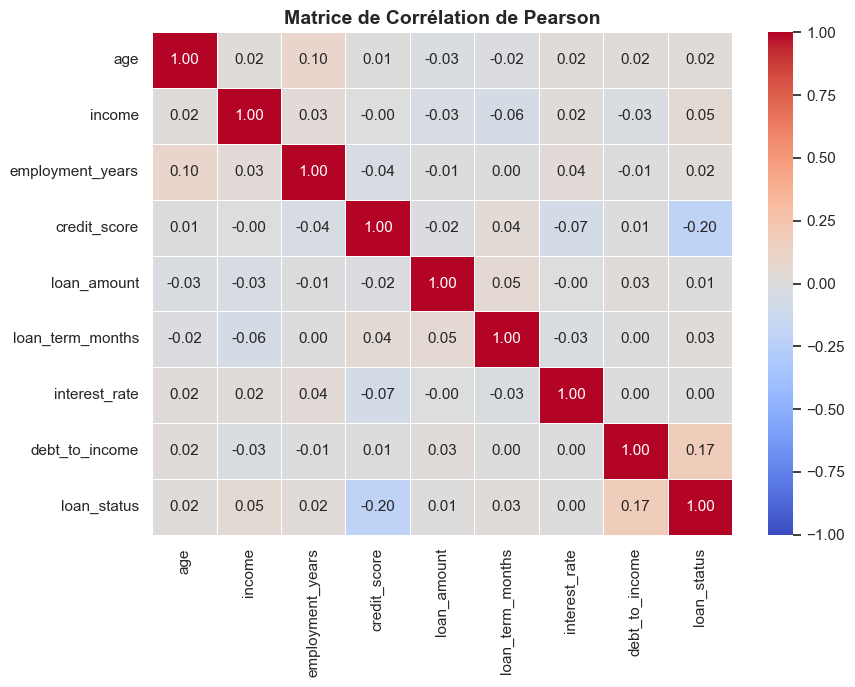

In [14]:
plt.figure(figsize=(9, 7))
corr_matrix = df[num_features + ['loan_status']].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matrice de Corrélation de Pearson", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Afin d'éviter tout phénomène de fuite de données (Data Leakage), nous effectuons le découpage en échantillons d'apprentissage (70 %) et de validation (30 %) avant la discrétisation et la transformation WoE.

Nous réalisons un test de Kolmogorov-Smirnov pour confirmer l'homogénéité des distributions entre le Train et le Test.

In [17]:
from sklearn.model_selection import train_test_split

# Séparation stratifiée sur la cible
train_df, test_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=42, 
    stratify=df['loan_status']
)

print(f"Taille Échantillon Apprentissage (Train) : {train_df.shape[0]} emprunteurs ({train_df['loan_status'].mean()*100:.2f}% de défaut)")
print(f"Taille Échantillon Validation (Test)     : {test_df.shape[0]} emprunteurs ({test_df['loan_status'].mean()*100:.2f}% de défaut)")

# Test d'homogénéité de Kolmogorov-Smirnov sur la variable clé credit_score
ks_stat, p_val = stats.ks_2samp(train_df['credit_score'], test_df['credit_score'])
print(f"\nTest Kolmogorov-Smirnov (credit_score Train vs Test) : p-value = {p_val:.4f}")
if p_val > 0.05:
    print("-> Cohortes homogènes (pas de différence significative de distribution).")
else:
    print("-> Attention : différence de distribution détectée.")

# Sauvegarde des fichiers d'apprentissage et de test
train_df.to_csv("../data/sets/datatrain_sample.csv", index=False)
test_df.to_csv("../data/sets/test_sample.csv", index=False)
print("\nFichiers 'train_sample.csv' et 'test_sample.csv' exportés avec succès.")

Taille Échantillon Apprentissage (Train) : 700 emprunteurs (57.71% de défaut)
Taille Échantillon Validation (Test)     : 300 emprunteurs (57.67% de défaut)

Test Kolmogorov-Smirnov (credit_score Train vs Test) : p-value = 0.2054
-> Cohortes homogènes (pas de différence significative de distribution).

Fichiers 'train_sample.csv' et 'test_sample.csv' exportés avec succès.
